# Intelligent Phishing Website Detection Using Machine Learning

# Part 3 – Machine Learning Model Training & Evaluation

This notebook trains and compares multiple machine learning models on the PhiUSIIL phishing dataset.

## Models
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- XGBoost

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Classification Report


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

try:
    from xgboost import XGBClassifier
except:
    XGBClassifier=None

import joblib


In [2]:
# Load Dataset
df=pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

TARGET='label'

X=df.drop(columns=[TARGET])

non_numeric_cols = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
cols_to_drop = [col for col in non_numeric_cols if col in X.columns]
X = X.drop(columns=cols_to_drop)

y=df[TARGET]


# Split FIRST
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale AFTER splitting
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print("Train:",X_train.shape)
print("Test :",X_test.shape)


Train: (188636, 50)
Test : (47159, 50)


In [3]:
models={
"Logistic Regression":LogisticRegression(max_iter=1000),
"Decision Tree":DecisionTreeClassifier(random_state=42),
"Random Forest":RandomForestClassifier(
    n_estimators=300,
    random_state=42
),
    "SVM":SVC(probability=True, max_iter=1000, random_state=42)
}

if XGBClassifier:
    models["XGBoost"]=XGBClassifier(
        eval_metric="logloss",
        random_state=42
)


Logistic Regression


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



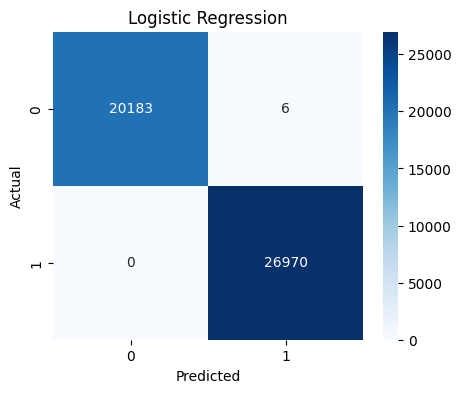

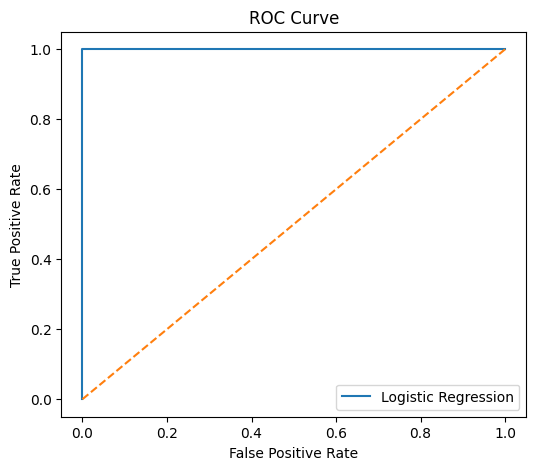

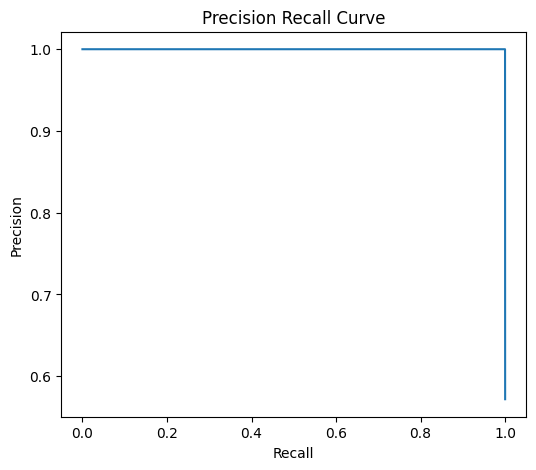

Decision Tree


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



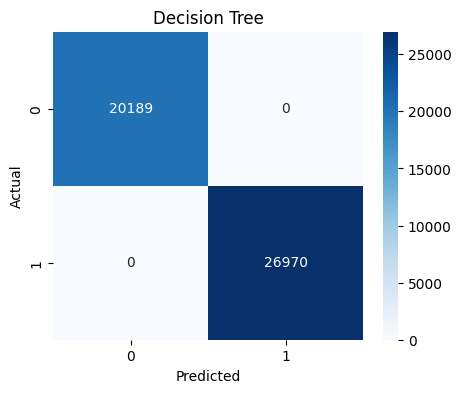

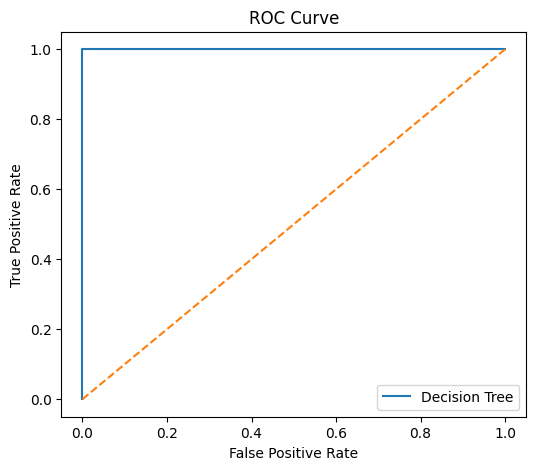

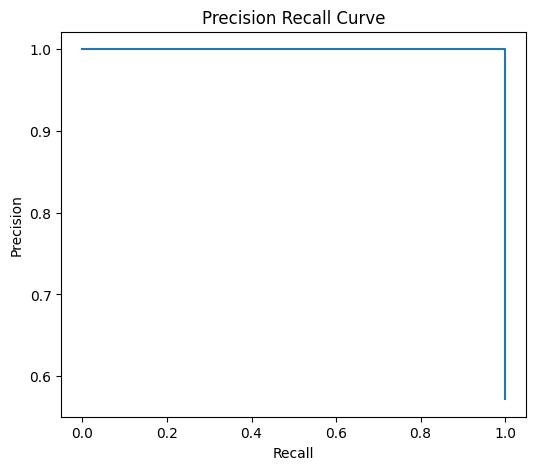

Random Forest


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



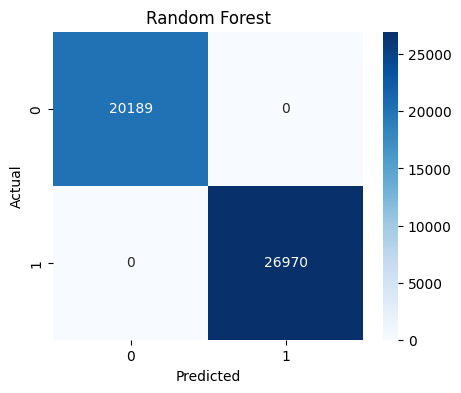

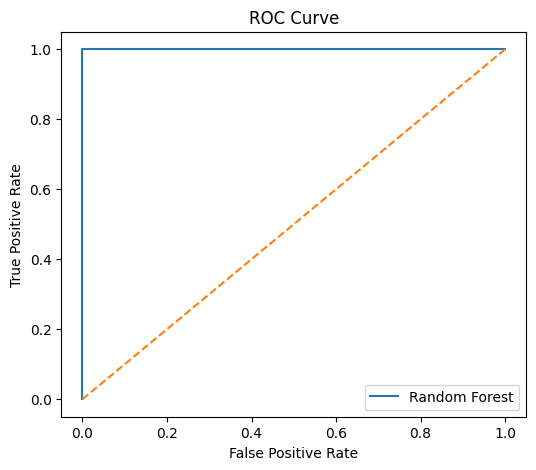

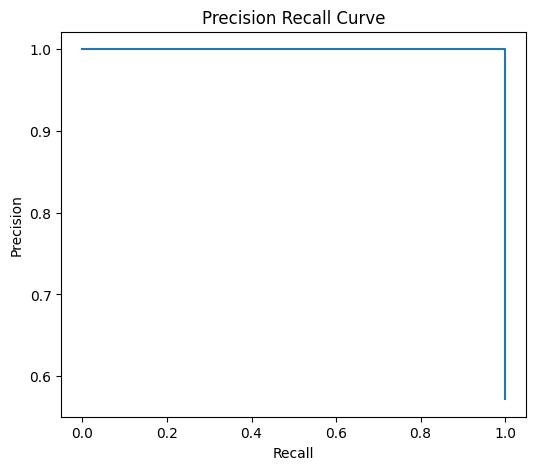

SVM


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



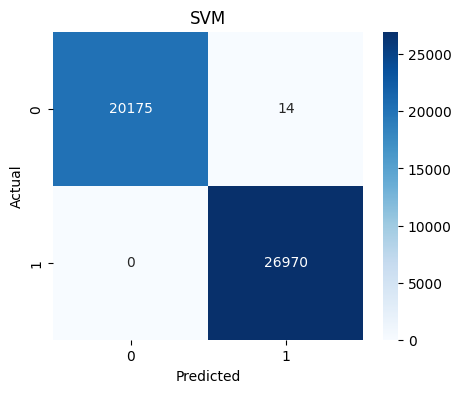

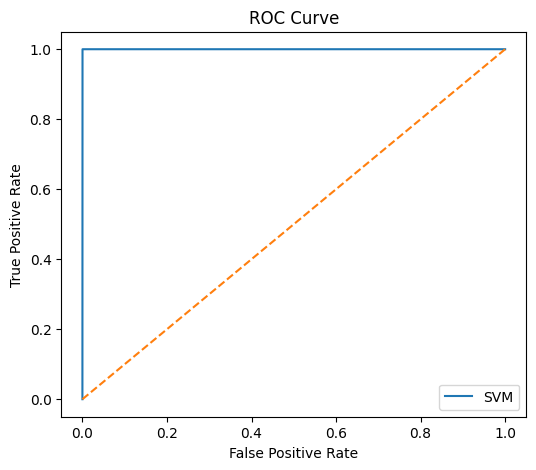

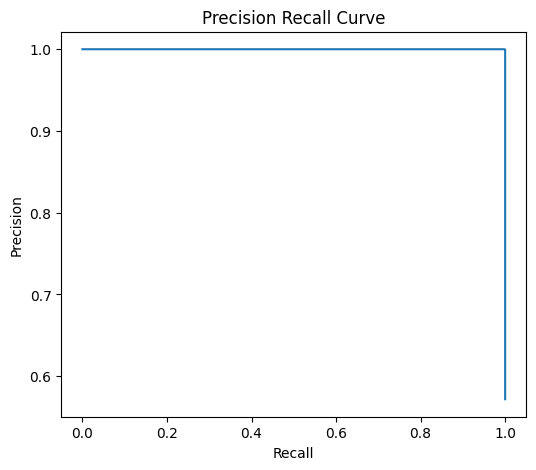

XGBoost


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



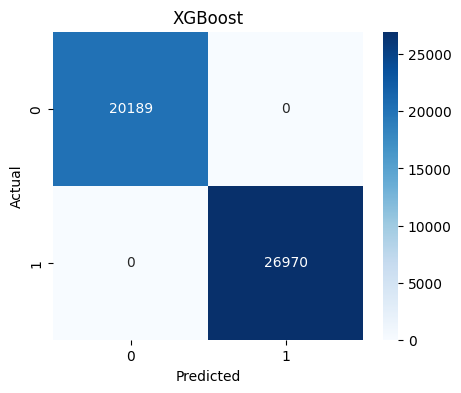

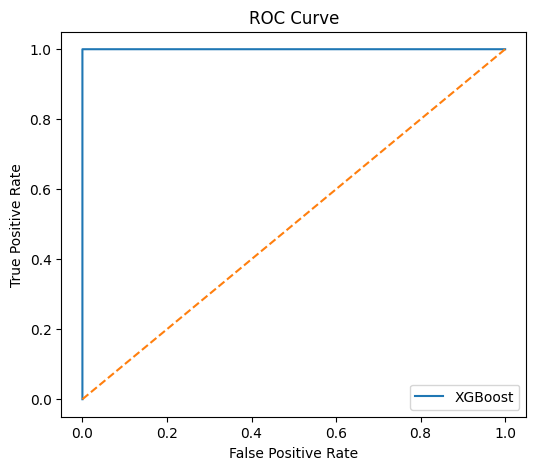

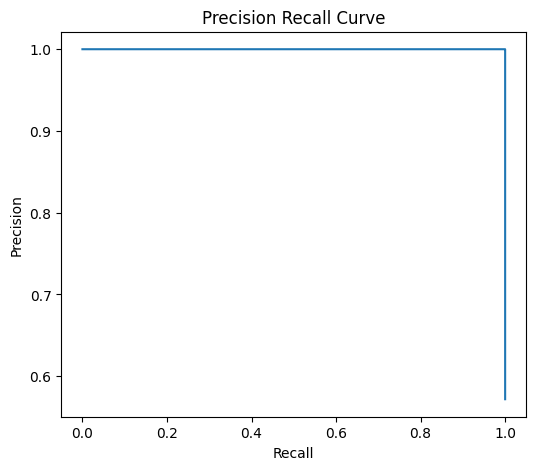

In [4]:
results=[]

best_model=None
best_name=""
best_acc=0

for name,model in models.items():

    print("="*80)
    print(name)

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    prob=model.predict_proba(X_test)[:,1]

    acc=accuracy_score(y_test,pred)
    pre=precision_score(y_test,pred)
    rec=recall_score(y_test,pred)
    f1=f1_score(y_test,pred)
    roc=roc_auc_score(y_test,prob)

    results.append([name,acc,pre,rec,f1,roc])

    print(classification_report(y_test,pred))

    cm=confusion_matrix(y_test,pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr,tpr,_=roc_curve(y_test,prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr,tpr,label=name)
    plt.plot([0,1],[0,1],'--')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    precision,recall,_=precision_recall_curve(y_test,prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall,precision)
    plt.title("Precision Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

    if acc>best_acc:
        best_acc=acc
        best_model=model
        best_name=name


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,1.000000,1.000000,1.0,1.000000,1.0
4,XGBoost,1.000000,1.000000,1.0,1.000000,1.0
2,Random Forest,1.000000,1.000000,1.0,1.000000,1.0
0,Logistic Regression,0.999873,0.999778,1.0,0.999889,1.0
3,SVM,0.999703,0.999481,1.0,0.999741,1.0


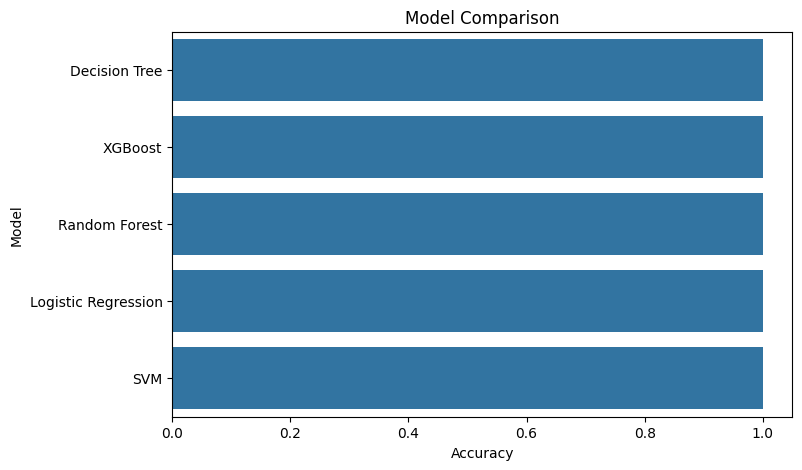

In [5]:
results_df=pd.DataFrame(
results,
columns=[
'Model',
'Accuracy',
'Precision',
'Recall',
'F1 Score',
'ROC AUC'
])

results_df=results_df.sort_values(
'Accuracy',
ascending=False
)

display(results_df)

plt.figure(figsize=(8,5))
sns.barplot(data=results_df,
            x='Accuracy',
            y='Model')
plt.title("Model Comparison")
plt.show()


In [6]:
print("Best Model:",best_name)
print("Accuracy :",best_acc)

joblib.dump(best_model,'phishing_model.pkl')

print("Saved phishing_model.pkl")


Best Model: Decision Tree
Accuracy : 1.0
Saved phishing_model.pkl


# Conclusion

This notebook successfully:

- Trained five machine learning models.
- Compared performance using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Generated Confusion Matrices.
- Plotted ROC Curves.
- Plotted Precision–Recall Curves.
- Selected the best-performing model.
- Saved the trained model as `phishing_model.pkl`.

The next notebook will focus on:

- Hyperparameter Tuning
- Cross Validation
- Feature Importance
- Explainable AI (SHAP)
- Risk Score Generation
- Deployment-ready Prediction Pipeline
